In [61]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [62]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)


Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)


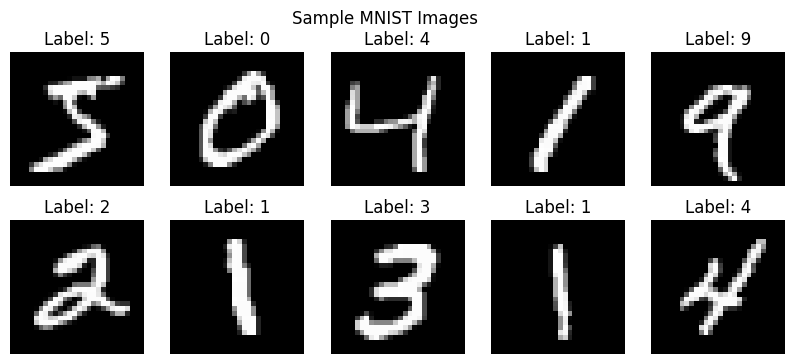

In [63]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample MNIST Images")
plt.show()

In [64]:

x_train = x_train / 255.0
x_test  = x_test  / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print("After reshape:", x_train.shape)


After reshape: (60000, 28, 28, 1)


In [65]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled ")

Model compiled 


In [67]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=64

)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9420 - loss: 0.1895 - val_accuracy: 0.9793 - val_loss: 0.0744
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9822 - loss: 0.0571 - val_accuracy: 0.9878 - val_loss: 0.0429
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9873 - loss: 0.0408 - val_accuracy: 0.9902 - val_loss: 0.0352
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9904 - loss: 0.0312 - val_accuracy: 0.9898 - val_loss: 0.0369
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9926 - loss: 0.0232 - val_accuracy: 0.9878 - val_loss: 0.0411


In [68]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9881 - loss: 0.0334

Final Test Accuracy: 98.81%


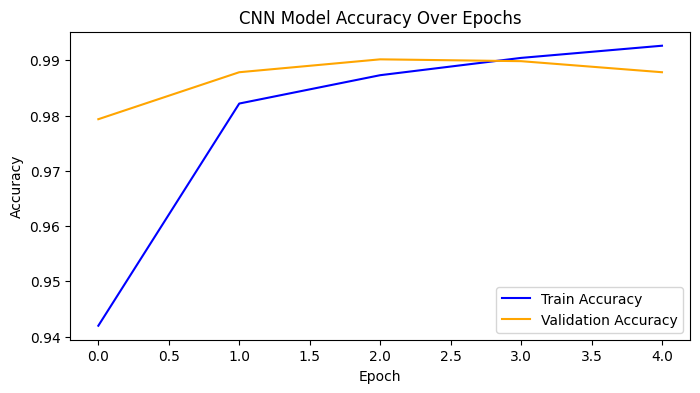

Graph saved ✅


In [69]:
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('CNN Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/content/accuracy_graph.png')
plt.show()
print("Graph saved ✅")

In [70]:
model.save('/content/digit_model.h5')
print("Model saved ✅")

Model saved ✅


In [12]:
from google.colab import files
files.download('/content/digit_model.h5')
files.download('/content/accuracy_graph.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:

sample_images = x_test[:10]
sample_labels = y_test[:10]
predictions = model.predict(sample_images)
predicted_digits = np.argmax(predictions, axis=1)

print("Actual labels:   ", sample_labels)
print("Predicted labels:", predicted_digits)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
Actual labels:    [7 2 1 0 4 1 4 9 5 9]
Predicted labels: [7 2 1 0 4 1 4 9 5 9]


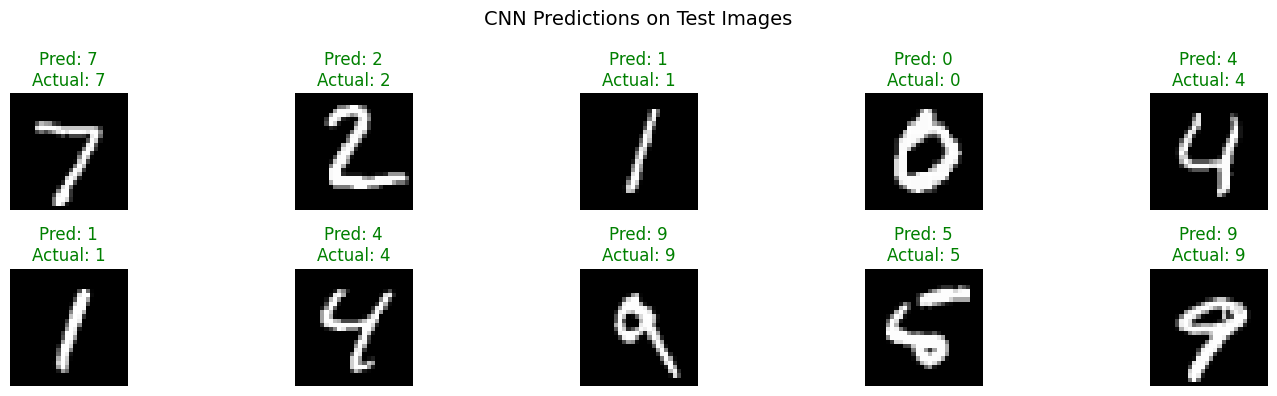

Saved 


In [72]:
plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(sample_images[i].reshape(28,28), cmap='gray')
    actual = sample_labels[i]
    predicted = predicted_digits[i]
    color = 'green' if actual == predicted else 'red'
    plt.title(f"Pred: {predicted}\nActual: {actual}", color=color)
    plt.axis('off')

plt.suptitle("CNN Predictions on Test Images", fontsize=14)
plt.tight_layout()
plt.savefig('/content/predictions.png')
plt.show()
print("Saved ")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step


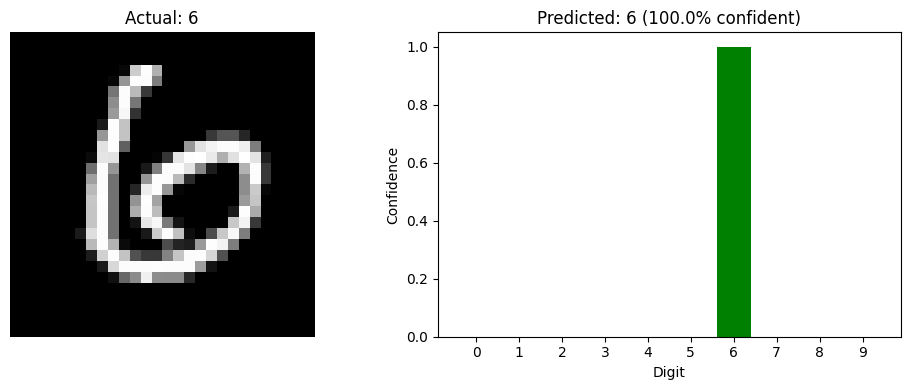

Model says: 6 with 100.0% confidence
Actual answer: 6


In [73]:

image_index = 11
single_image = x_test[image_index]
actual_label = y_test[image_index]

# Predict
pred = model.predict(single_image.reshape(1, 28, 28, 1))
confidence = np.max(pred) * 100
predicted = np.argmax(pred)

# Show image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(single_image.reshape(28,28), cmap='gray')
plt.title(f"Actual: {actual_label}")
plt.axis('off')

# bar chart
plt.subplot(1, 2, 2)
plt.bar(range(10), pred[0], color='steelblue')
plt.bar(predicted, pred[0][predicted], color='green')
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('Confidence')
plt.title(f"Predicted: {predicted} ({confidence:.1f}% confident)")
plt.tight_layout()
plt.savefig('/content/confidence_chart.png')
plt.show()
print(f"Model says: {predicted} with {confidence:.1f}% confidence")
print(f"Actual answer: {actual_label}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 1000x800 with 0 Axes>

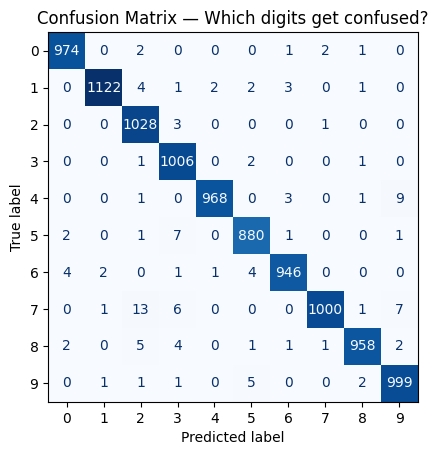

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
all_predictions = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

plt.figure(figsize=(10,8))
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Which digits get confused?')
plt.savefig('/content/confusion_matrix.png')
plt.show()

In [75]:
from google.colab import files
files.download('/content/predictions.png')
files.download('/content/confidence_chart.png')
files.download('/content/confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [108]:
from google.colab import files
uploaded = files.upload()


Saving Screenshot 2026-09-20 164313.png to Screenshot 2026-09-20 164313.png


In [109]:
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

Uploaded file: Screenshot 2026-09-20 164313.png


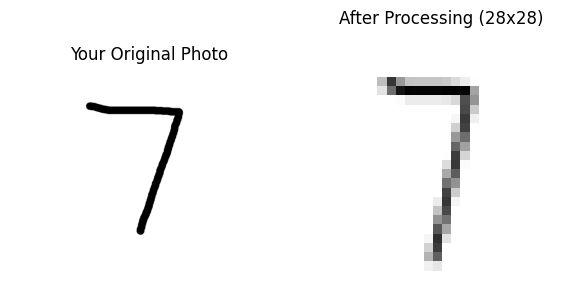

In [110]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
img = Image.open(filename)
img = img.convert('L')
img = img.resize((28, 28))
img_array = np.array(img)
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(Image.open(filename))
plt.title("Your Original Photo")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_array, cmap='gray')
plt.title("After Processing (28x28)")
plt.axis('off')

plt.tight_layout()
plt.show()

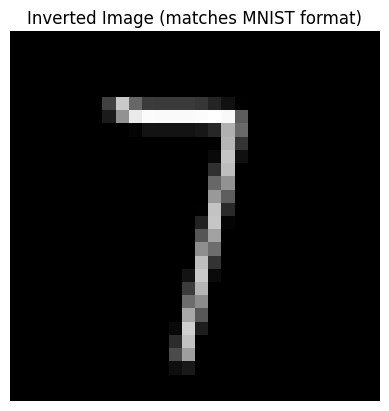

In [111]:
img_array = 255 - img_array

plt.imshow(img_array, cmap='gray')
plt.title("Inverted Image (matches MNIST format)")
plt.axis('off')
plt.show()

In [112]:

img_normalized = img_array / 255.0


img_input = img_normalized.reshape(1, 28, 28, 1)


prediction = model.predict(img_input)
predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

print(f" Model Prediction: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
 Model Prediction: 7
Confidence: 98.01%


/tmp/ipykernel_677/477862501.py:25: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677/477862501.py:26: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/my_handwriting_prediction.png')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


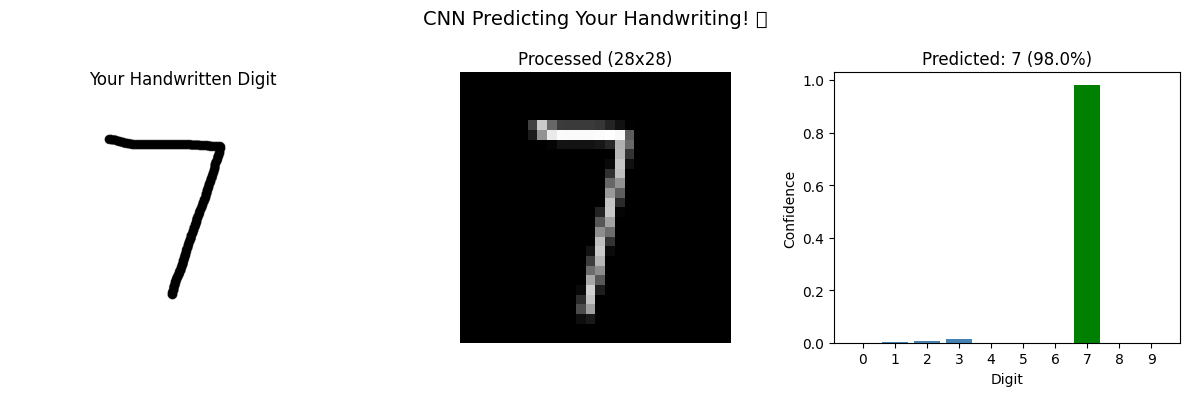

In [113]:
plt.figure(figsize=(12, 4))

# Show your original photo
plt.subplot(1, 3, 1)
plt.imshow(Image.open(filename))
plt.title("Your Handwritten Digit")
plt.axis('off')

# Show processed image
plt.subplot(1, 3, 2)
plt.imshow(img_array, cmap='gray')
plt.title("Processed (28x28)")
plt.axis('off')

# Show confidence chart
plt.subplot(1, 3, 3)
plt.bar(range(10), prediction[0], color='steelblue')
plt.bar(predicted_digit, prediction[0][predicted_digit], color='green')
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('Confidence')
plt.title(f"Predicted: {predicted_digit} ({confidence:.1f}%)")

plt.suptitle("CNN Predicting Your Handwriting! 🎉", fontsize=14)
plt.tight_layout()
plt.savefig('/content/my_handwriting_prediction.png')
plt.show()

In [114]:
from google.colab import files
files.download('/content/my_handwriting_prediction.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [115]:
from google.colab import files

files.download('/content/accuracy_graph.png')
files.download('/content/predictions.png')
files.download('/content/confidence_chart.png')
files.download('/content/confusion_matrix.png')
files.download('/content/my_handwriting_prediction.png')
files.download('/content/digit_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>